*This notebook is a final project for CS 345: Machine Learning Foundations and Practice at Colorado State University.
Original versions were created by Rose Ordway and Hallie Gurr*

# **Predicting Valorant Match Outcomes Using Performance Metrics**
_By Hallie Gurr and Rose Ordway_

## **Introduction**

Valorant is a competitive first-person tactical shooter developed by Riot Games that has gained popularity in the esports scene. In the game, two teams of five players each—attackers and defenders—compete in rounds to either plant or defuse a device known as the "spike" at designated sites. Players can choose from 29 unique agents, each equipped with their own unique abilities. During each round, players have the option to select from 20 different weapons. A team can win a round by eliminating all opposing players or by successfully completing their objective, which involves either planting and defending the spike or preventing it from being planted, and if planted, defusing it before it detonates. To succeed, teams must rely on precise shooting skills and strategic use of their abilities. The first team to win 13 rounds wins the match.

Due to Valorant's strategic complexity, match outcomes are influenced by a combination of mechanical skill, tactical decision-making, and team composition. Factors such as player performance statistics, in-game economy management, and agent role distribution play a significant role in determining success. These interactions are complex and nonlinear, making the game an ideal candidate for machine learning analysis.

Our objective is to develop and evaluate supervised machine learning models that predict the winner of a Valorant match using aggregated team-level statistics. The features considered include kills, assists, deaths, economy rating, headshot accuracy, and the distribution of agent roles (Duelist, Sentinel, Controller, and Initiator). We use logistic regression as a baseline interpretable model and support vector machines (SVMs) to capture more complex decision boundaries. By comparing these approaches, we analyze their predictive performance and assess which factors most strongly contribute to match outcomes.

## **Data Description**

The *Valorant Pro Matches - Full Data*, created by Joshua Broas on Kaggle, compiles information on professional and semi-professional matches from the video game Valorant. The database is in SQLite format and covers matches from April 25, 2020, to January 1, 2022. The database was compiled by scraping from VLR.gg, a website devoted to Valorant esports coverage. While the database aims to capture all available matches, it is vital to note that approximately 4% (~400 out of ~11,500) of the match statistics—mainly affecting the first 200 matches—could not be included due to inconsistent HTML/CSS formatting.

The database consists of four datasets: `Matches`, `Games`, `Game_Rounds`, and `Game_Scoreboard`, each representing a different level of match detail.

*  The `Matches` dataset contains 12 columns and 7,818 rows, providing overall match information including participating teams, event details, and final scores.
*  The `Games` dataset consists of 36 columns and 15,888 rows, offering detailed round-level information, such as maps played, team sides (attacker/defender), and the outcomes of pistol, economic, semi-buy, and full-buy rounds.
*  The `Game_Rounds` dataset includes 4 columns and 15,531 rows, detailing round-by-round information, including round winners, score progression, team economy, and buy types.
*  The `Game_Scoreboard` dataset has 28 columns and 157,939 rows, recording detailed player statistics such as kills, deaths, assists, first bloods, and clutch performances.

The database possesses numeric, categorical, and datetime fields, as well as JSON format in the `Game_Rounds` dataset.

The datasets are linked hierarchically through common variables. The variable `match_id` links `Matches` and `Games`, and `Games` links both `Game_Rounds` and `Game_Scoreboard` through the variable `game_id`.

    Matches ➜ Games ➜ Game_Rounds & Game_Scoreboard

The database offers a comprehensive, multi-level view of professional Valorant matches, from overall match outcomes to detailed round-level information and individual player performance. It is appropriate for in-depth analyses of team strategies, player performance, and match dynamics; however, it requires careful handling of JSON fields and missing values.

*Database link: https://www.kaggle.com/datasets/visualize25/valorant-pro-matches-full-data*

## **Methodology**

### ***Preprocessing Data***

#### *1. Data Source and Environment Setup*
Data was extracted from the SQLite database, valorant.sqlite. This database contains records of professional and semi-professional Valorant games. Two primary datasets were utilized: the `Games` dataset, which provides outcomes at the match level, and the `Game_Scoreboard` dataset, which includes player-level performance statistics. The data were retrieved using SQL queries executed within a Python environment, and only records with complete required fields were retained.

#### *2. Player-Level Feature Extraction*
Player performance statistics were extracted from the `Game_Scoreboard` dataset for each match. The selected features include `Kills`, `Deaths`, `Assists`, headshot percentage (`HS_%`), and economy score (`Econ`). These metrics were chosen to capture individual mechanical performance and in-game resource management.

#### *3. Team Composition Feature Engineering*
Each player's chosen agent was classified into one of four standardized roles: `Duelist`, `Controller`, `Initiator`, or `Sentinel`. For every match and team, we counted the number of players assigned to each role. If a role category was missing, it was recorded as zero to maintain a consistent feature space across all teams and matches.

#### *4. Feature Integration*
The team composition features were integrated with player performance data using game and team identifiers. This ensured that each player’s statistics included both individual performance and team composition data.

#### *5. Target Variable Construction*
Match outcomes were obtained from the `Games` dataset. The winning team for each match was identified and linked to their respective team abbreviations. A binary target variable, TeamWin, was assigned to each player observation, with 1 indicating the player’s team won the match and 0 indicating a loss.

#### *6. Data Cleaning and Validation*
After removing rows with missing values, we verified that each match had the expected 10 player observations. The final dataset included nine input features: five metrics related to player performance (`Kills`, `Deaths`, `Assists`, headshot percentage (`HS_%`), and economy score (`Econ`)) and four variables representing team composition (the counts of `Duelists`, `Controllers`, `Initiators`, and `Sentinels`). These features were used in conjunction with the binary target variable, `TeamWin`.

#### *7. Train/Test Split and Feature Scaling*
The dataset includes numeric player performance metrics and team composition counts. The target variable, TeamWin, indicates a win (represented as 1) or a loss (represented as 0). Numeric features were standardized using the StandardScaler, while the role counts were left unscaled. The dataset was divided into training (70%) and test (30%) sets, utilizing a fixed random seed to ensure reproducibility.

### ***Logistic Regression***

#### *1. Model Training*
The model was trained on scaled data from Valorant matches to predict their outcomes. Player statistics and role counts were standardized, ensuring that each feature contributed equally. Throughout the training process, the model learned to determine the importance of each feature to accurately reflect observed match results and generate winning probabilities.

#### *2. Model Evaluation*
The model's performance was assessed on a test set using metrics such as accuracy, precision, recall, and overall predictive ability. Probabilities were converted into binary win/loss predictions utilizing a standard decision threshold.

#### *3. Prediction of Team Compositions*
Different team compositions were tested by combining average player statistics with various role counts. The model generated predicted win probabilities for each setup, enabling identification of the most favorable team configurations.


#### *4. Identifying Strongest Predictors*
Feature importance was evaluated based on the model's parameters. Team composition emerged as the strongest predictor of match outcome, followed by individual player statistics like kills and deaths.

#### *5. Best Team Compositions*
By averaging predicted probabilities based on realistic player statistics, the model identified the optimal team composition. The recommended setup consisted of one Duelist, one Controller, no Initiators, and three Sentinels, which were projected to have the highest chance of winning.

### ***Support Vector Machine (SVM)***

#### *1. Model Training*
A Linear Support Vector Classification (`LinearSVC`) model was chosen for its interpretability and efficiency when handling linearly separable data. To generate probability estimates, the SVM was wrapped with `CalibratedClassifierCV` using three-fold cross-validation. The model was trained on scaled training data, and initial performance was evaluated using test set accuracy.

#### *2. Model Evaluation and Visualization*
Model performance was evaluated using several metrics and visualizations:


*   **Confusion Matrix:** This displayed the counts of correct and incorrect predictions, allowing us to assess model accuracy for wins and losses.

*   **ROC Curve and AUC:** This illustrated the model’s ability to distinguish between wins and losses, with the area under the curve (AUC) providing a measure of overall performance.

*   **Precision-Recall Curve and Average Precision:** This assessed the trade-off between precision and recall across different probability thresholds.
*    **Predicted Probability Histogram:** This displayed the distribution of predicted win probabilities for actual wins and losses, reflecting the model’s level of confidence.


#### *3. Feature Importance*
The feature coefficients from the trained linear SVM were extracted to assess the impact of each metric and player role on the predicted match outcomes. The features were ranked based on the absolute value of their coefficients, and a horizontal bar chart was created to visualize their relative importance.

#### *4. Prediction of Team Compositions*
The trained model was utilized to predict win probabilities for specific team compositions. We combined average numeric metrics with different role counts, scaled the features, and used the SVM to estimate win probabilities for hypothetical teams. This process enabled the identification of the most advantageous team compositions.

#### *5. Decision Boundary Visualization*
To illustrate how the Support Vector Machine (SVM) distinguishes between wins and losses, a two-dimensional plot of kills versus deaths was created. The decision boundary, derived from the model’s coefficients, was overlaid on the scatter plot. This visually demonstrates how the linear SVM distinguishes between winning and losing outcomes in the feature space.


### ***Logistic Regression & Linear Support Vector Machine (SVM)***

#### *1. Model Training*
Both Linear SVM (with probability calibration through CalibratedClassifierCV and 3-fold cross-validation) and Logistic Regression were trained using scaled training data. These models were utilized to predict match outcomes, generating probabilities for evaluation.

#### *2. Model Evaluation*
The performance of the models was assessed on the test set using metrics such as Accuracy, AUC, Average Precision, F1-Score, Precision, and Recall. This allowed for a direct comparison of the classification abilities of the two models.

#### *3. Prediction of Team Compositions*  
The trained models were employed to estimate win probabilities for specific team compositions. Average player metrics were combined with different counts of roles, features were scaled, and the models produced predicted probabilities to identify advantageous team setups.

## **Implementation & Results**

#### ***Preprocessing Data***

In [229]:
# Environment Setup
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [230]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Remove rows with missing values
def removeNanRows(X):
    df = pd.DataFrame(X)
    return df.dropna().values

# Load mappings for team abbreviations and agent roles
from maps.team_map import TEAM_MAP
from maps.role_map import ROLE_MAP

# Retrieve GameID and Winner from the Games table
def getGames(conn, limit=None):
    headers = ["GameID","Winner"]
    selections = ", ".join(headers)
    conditions = " AND ".join([f"{h} IS NOT NULL" for h in headers])
    query = f"""
    SELECT {selections}
    FROM Games
    WHERE {conditions}
    LIMIT {-1 if limit is None else limit};
    """
    return pd.read_sql_query(query, conn)

# Compute team composition counts for each role per game
def generateTeamCompList(scoreboard):
    sb = scoreboard.copy()
    sb["Role"] = sb["Agent"].map(ROLE_MAP)
    sb_with_role = sb.dropna(subset=["Role"])  # Keep only valid roles
    comp = (
        sb_with_role
        .groupby(["GameID", "TeamAbbreviation", "Role"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Duelist", "Controller", "Initiator", "Sentinel"], fill_value=0)
    )
    return comp

# Retrieve player-level scoreboard data
def getScoreboard(conn, limit=None):
    headers = ["GameID","TeamAbbreviation", "PlayerID", "Agent", "Kills", "Deaths",
               "Assists", "HS_Percent", "Econ"]
    selections = ", ".join(headers)
    conditions = " AND ".join([f"{h} IS NOT NULL" for h in headers])
    query = f"""
    SELECT {selections}
    FROM Game_Scoreboard
    WHERE {conditions}
    LIMIT {-1 if limit is None else limit};
    """
    return pd.read_sql_query(query, conn)

# Merge team composition counts into the player-level scoreboard
def assignTeamCompToScoreboard(scoreboard, df_teamcomp):
    df_teamcomp = df_teamcomp.reset_index()  # Reset index for merging
    merged = scoreboard.merge(
        df_teamcomp,
        on=["GameID", "TeamAbbreviation"],
        how="left"  # Keep all scoreboard rows
    )
    return merged

# Add the binary TeamWin target for each player
def addWinnerToScoreboard(conn, scoreboard):
    games = getGames(conn)
    game_winner_map = dict(zip(games["GameID"], games["Winner"]))
    scoreboard["WinningAbbrev"] = scoreboard["GameID"].map(game_winner_map).map(TEAM_MAP)
    scoreboard["TeamWin"] = (scoreboard["TeamAbbreviation"] == scoreboard["WinningAbbrev"]).astype(int)
    return scoreboard

# Generate the final ML-ready dataset
def generateMLReadySB(conn, limit=None):
    scoreboard = getScoreboard(conn, limit=limit)
    df_teamcomp = generateTeamCompList(scoreboard)
    scoreboard = assignTeamCompToScoreboard(scoreboard, df_teamcomp)
    scoreboard = addWinnerToScoreboard(conn, scoreboard)
    feature_cols = ["Kills", "Deaths", "Assists", "HS_Percent", "Econ",
                    "Duelist", "Controller", "Initiator", "Sentinel", "TeamWin"]
    features = scoreboard[feature_cols].to_numpy()
    return removeNanRows(features)

# Print missing player-role statistics for validation
def getMissingPlayerStats(comp, conn, dataLimit):
    scoreboard = getScoreboard(conn, limit=dataLimit)
    comp["RoleCount"] = comp.sum(axis=1)
    unique_ids = scoreboard["GameID"].nunique() * 10
    print(f"Actual number of entries: {unique_ids}")
    print(f"Number of entries with role: {comp['RoleCount'].sum()}")
    print(f"Number of missing entries: {unique_ids - comp['RoleCount'].sum()}")
    print(f"Percent missing: {(unique_ids - comp['RoleCount'].sum()) / unique_ids*100:.2f}%")

# Scale numeric features for modeling
def transform_features(X_raw, scale_cols, scaler):
    X_scaled = X_raw.astype(float).copy()
    X_scaled[:, scale_cols] = scaler.transform(X_raw[:, scale_cols])  # Standardize selected columns
    return X_scaled

In [231]:
# Connect to the SQLite database
db_path = "data/valorant.sqlite"
conn = sqlite3.connect(db_path)

# Check for existing table names in the database
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

# Display table names
display(tables)

,name
0,Matches
1,Games
2,Game_Rounds
3,Game_Scoreboard


Verified that the database contains the required tables for analysis.

In [232]:
# Set limit on number of games to process (None = no limit)
dataLimit = None

# Generate the ML-ready scoreboard dataset
mlscoreboard = generateMLReadySB(conn, limit=dataLimit)

# Show dataset shape
print(mlscoreboard.shape)

# Convert to DataFrame with feature columns
df = pd.DataFrame(mlscoreboard, columns=[
    "Kills", "Deaths", "Assists", "HS_%", "Econ",
    "Duelist", "Controller", "Initiator", "Sentinel", "TeamWin"
])

# Display the first 10 rows
display(df.head(10))

(147702, 10)


,Kills,Deaths,Assists,HS_%,Econ,Duelist,Controller,Initiator,Sentinel,TeamWin
0,24.0,10.0,3.0,0.31,74.0,1.0,1.0,2.0,1.0,1.0
1,16.0,10.0,7.0,0.16,67.0,1.0,1.0,2.0,1.0,1.0
2,17.0,9.0,8.0,0.27,58.0,1.0,1.0,2.0,1.0,1.0
3,17.0,12.0,2.0,0.19,48.0,1.0,1.0,2.0,1.0,1.0
4,5.0,13.0,3.0,0.22,21.0,1.0,1.0,2.0,1.0,1.0
5,15.0,16.0,5.0,0.31,62.0,0.0,2.0,2.0,1.0,0.0
6,12.0,14.0,6.0,0.22,73.0,0.0,2.0,2.0,1.0,0.0
7,12.0,16.0,2.0,0.18,42.0,0.0,2.0,2.0,1.0,0.0
8,9.0,15.0,1.0,0.36,42.0,0.0,2.0,2.0,1.0,0.0
9,6.0,18.0,3.0,0.22,21.0,0.0,2.0,2.0,1.0,0.0


Confirmed that the ML-ready dataset contains player statistics and team composition features for modeling match outcomes.

In [233]:
# Calculate and display missing player-role statistics
getMissingPlayerStats(generateTeamCompList(getScoreboard(conn, limit=dataLimit)), conn, dataLimit)

Actual number of entries: 148480
Number of entries with role: 147702
Number of missing entries: 778
Percent missing: 0.52%


Missing player-role entries are minimal (0.52%), so no further imputation is necessary.

In [234]:
# Data Preparation for Modeling: Train/Test Split and Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Split features and target
X = mlscoreboard[:, :-1]
y = mlscoreboard[:, -1]

# Columns to scale (numeric)
scale_cols = [0, 1, 2, 3, 4]

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Fit scaler on training data and apply to train/test sets
scaler = StandardScaler()
scaler.fit(X_train[:, scale_cols])

X_train_scaled = transform_features(X_train, scale_cols, scaler)
X_test_scaled  = transform_features(X_test, scale_cols, scaler)
X_scaled_all = transform_features(X, scale_cols, scaler)

### **Logistic Regression**

Here are the important concepts for calculating a binary prediction using logistic regression. We will break down how these formulas are used to predict Valorant match winners based on the match data.

| Concept                  | Formula                                                                           |
|--------------------------|-----------------------------------------------------------------------------------|
| Sigmoid                  | $ \sigma(z) = \frac{1}{1 + e^{-z}} $                                              |
| Hypothesis               | $ h_\theta(x) = \sigma(\theta^T x) $                                              |
| Single sample likelihood | $ h_\theta(x)^y \,(1 - h_\theta(x))^{1-y} $                                       |
| Dataset likelihood       | $ \prod_{i=1}^{m} h_\theta(x^{(i)})^{y^{(i)}} (1 - h_\theta(x^{(i)}))^{1-y^{(i)}} $ |
| Log-likelihood           | $ \sum_{i=1}^m \left[ y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log(1 - h_\theta(x^{(i)})) \right] $ |
| Gradient                 | $ \frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m (y^{(i)} - h_\theta(x^{(i)}))\, x_j^{(i)} $ |
| Decision rule            | $ h_\theta(x) \ge 0.5 \;\Rightarrow\; 1 $                                         |


We can broadly simplify logistic regression into three components:

**Sigmoid (prediction function):**  
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

**Log-likelihood (training objective):**  
$$ \ell(\theta) = \sum_{i=1}^m \left[ y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log(1 - h_\theta(x^{(i)})) \right] $$

**Gradient (parameter update rule):**  
$$ \frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m (y^{(i)} - h_\theta(x^{(i)}))\, x_j^{(i)} $$

For logistic regression, the model produces a probability estimate using the sigmoid function. The likelihood function is used during training to assess the probability of the model's current parameters. We then take the logarithm of this function (the log-likelihood) to avoid numerical issues and simplify calculations.

$$
\textbf{Product to Sum Transformation Using Logarithms}
$$

$$
\log\left( \prod_{i=1}^{m} a_i \right)
= \sum_{i=1}^{m} \log(a_i)
$$

Using logarithms, we can convert products into sums, which makes optimization easier and faster, as sums are computationally cheaper to calculate than products. This also helps keep our numerical values intact, avoiding numerical underflow.

$$
\textbf{Apply this to the logistic regression likelihood:}
$$
$$
L(\theta)
= \prod_{i=1}^{m}
\left( h_\theta(x^{(i)}) \right)^{y^{(i)}}
\left( 1 - h_\theta(x^{(i)}) \right)^{1 - y^{(i)}}
$$

$$
\ell(\theta)
= \log L(\theta)
= \log \left(
\prod_{i=1}^{m}
\left( h_\theta(x^{(i)}) \right)^{y^{(i)}}
\left( 1 - h_\theta(x^{(i)}) \right)^{1 - y^{(i)}}
\right)
$$
$$
\text{Using the log product rule:}
$$
$$
\ell(\theta)
= \sum_{i=1}^{m}
\log \left[
\left( h_\theta(x^{(i)}) \right)^{y^{(i)}}
\left( 1 - h_\theta(x^{(i)}) \right)^{1 - y^{(i)}}
\right]
$$
$$
\text{Using } \log(a^b) = b \log(a):
$$
$$
\ell(\theta)
= \sum_{i=1}^{m}
\left[
y^{(i)} \log h_\theta(x^{(i)})
+ (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))
\right]
$$

In [235]:
import pandas as pd

df = pd.DataFrame(
    X_scaled_all,
    columns=["Kills", "Deaths", "Assists", "HS_%", "Econ", "Duel", "Ctrl", "Init", "Sen"]
)

print("X values for entry 0:")
display(df.head(1))


X values for entry 0:


,Kills,Deaths,Assists,HS_%,Econ,Duel,Ctrl,Init,Sen
0,1.725369,-1.162935,-0.711764,0.823754,1.073494,1.0,1.0,2.0,1.0


#### Logistic Regression Example
Example to see how logistic regression finds its weights.
We are going to use our first row of data using kills and deaths.
$$
\theta =
\begin{bmatrix}
\text{Bias} \\
\text{KWeight} \\
\text{DWeight}
\end{bmatrix}
=
\begin{bmatrix}
1 \\
0.1 \\
0.1
\end{bmatrix},
\qquad
x =
\begin{bmatrix}
1 \\
1.725369 \\
-1.162935
\end{bmatrix},
\qquad
y = 1 \ (\text{win})
$$

We must get a hypothesis using the values above:
$$
h_\theta(x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

$z$ is equal to $\theta^T x$ which the dot product of our perameter vector $\theta$ and our input vector $x$:
$$
z = \theta_0 + \theta_1 x_1 + \theta_2 x_2
$$

$$
z = 1 + (0.1)(1.725369) + (0.1)(-1.162935) = 1.0562434
$$

$$
h_\theta(x) = \frac{1}{1 + e^{-1.0562434}} \approx 0.741972
$$

For logistic regression with negative log-likelihood, the gradient for **one sample** is:

$$
\frac{\partial J}{\partial \theta_j} = (h_\theta(x) - y)\, x_j
$$

For a **full dataset** of $m$ samples, the total gradient is the sum over all examples:
$$
\frac{\partial J}{\partial \theta_j}
= \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}
$$




Calculating the gradients:
$$
\frac{\partial J}{\partial \theta_0}
= (0.741972 - 1)\cdot 1
\approx -0.258028
$$

$$
\frac{\partial J}{\partial \theta_1}
= (0.741972 - 1)\cdot 1.725369
\approx -0.445194
$$

$$
\frac{\partial J}{\partial \theta_2}
= (0.741972 - 1)\cdot (-1.162935)
\approx 0.300070
$$



Gradient descent update with learning rate $\alpha = 0.1$:
$$
\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}
$$

$$
\theta_0' = 1 - 0.1(-0.258028) \approx 1.025803
$$

$$
\theta_1' = 0.1 - 0.1(-0.445194) \approx 0.144519
$$

$$
\theta_2' = 0.1 - 0.1(0.300070) \approx 0.069993
$$



Updated parameter vector:
$$
\theta' =
\begin{bmatrix}
1.025803 \\
0.144519 \\
0.069993
\end{bmatrix}
$$

This is how the logistic regression model continues to learn. Below, we show how the maximum number of iterations affects the accuracy of our model. The iterations affect how many times the gradient is updated in our final prediction algorithm.

The update rule is $ \theta_j^{(t+1)} = \theta_j^{(t)} - \alpha \,\frac{\partial J}{\partial \theta_j} $ where $t$ is our iteration up to ```python max_iter=1000```.

While we can improve accuracy, we can only get it accurate up to a point. The accuracy of our set is shown below. Our improvements in accuracy will diminish as the shifts in our gradient parameters become too small to change the model. Different algorithms for gradient descent vary in how they use the entire gradient, a partial gradient, or a single entry to update the parameters. The algorithm used in this project is a Batch Gradient Descent.

Bonus Info:

Scikit-learn uses *Limited-memory Broyden–Fletcher–Goldfarb–Shanno* (LBFGS) instead of gradient descent. Gradient descent is a more straightforward way to update parameters, whereas LBFGS is more advanced and converges faster for logistic regression.

```python
lr = LogisticRegression(solver=”lbfgs”)
```

$$
\theta^{(t+1)} = \theta^{(t)} - \alpha \,\nabla J\big(\theta^{(t)}\big)
$$

In [236]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
# Testing max iters on Logistic Regression
iters = [1,2,3,4,5,10,25,50,75,100]
data = []

for iter in iters:
    lr = LogisticRegression(max_iter=iter, random_state=42)
    lr.fit(X_train_scaled, y_train)
    accuracy = lr.score(X_test_scaled, y_test)
    data.append((iter, accuracy))

pd.DataFrame(data, columns=["Max Iterations", "Accuracy"])

,Max Iterations,Accuracy
0,1,0.750784
1,2,0.764776
2,3,0.785448
3,4,0.793031
4,5,0.807294
5,10,0.811288
6,25,0.812913
7,50,0.812913
8,75,0.812913
9,100,0.812913


#### Testing Logistic Regression
$$
x_0 = [24,\; 10,\; 3,\; 0.31,\; 74,\; 1,\; 1,\; 2,\; 1]
$$

In [237]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)


test_data = X[0]

print("Raw features for entry", 0, ":")
test_df = pd.DataFrame(
    [test_data],
    columns=["Kills", "Deaths", "Assists", "HS_%", "Econ", "Duel", "Ctrl", "Init", "Sen"]
)
display(test_df)

test_data_scaled = transform_features(test_data.reshape(1, -1), scale_cols, scaler)

probs = lr.predict_proba(test_data_scaled)
win_prob = probs[0, 1]

print(f"Predicted win probability for entry {0}: {win_prob:.4f}")


Raw features for entry 0 :


,Kills,Deaths,Assists,HS_%,Econ,Duel,Ctrl,Init,Sen
0,24.0,10.0,3.0,0.31,74.0,1.0,1.0,2.0,1.0


Predicted win probability for entry 0: 0.9825


Using our decision rule

$$
h_\theta(x) \ge 0.5 \;\Rightarrow\; 1
$$

We can conclude that $0.9825 \ge 0.5$ so someone with these stats is likely to win the match.

#### Identifying Strongest Predictor
Let's use the model's weights to identify the strongest predictor of winning a match. We will combine the weights of the different roles and think of it as one predictor **team composition**.

$$
W =
\begin{bmatrix}
\text{KWeight} \\
\text{DWeight} \\
\text{AWeight} \\
\text{HSWeight} \\
\text{EconWeight} \\
\text{DuelWeight} \\
\text{CtrlWeight} \\
\text{InitWeight} \\
\text{SenWeight}
\end{bmatrix}
\qquad
W_{\text{reduced}} =
\begin{bmatrix}
\text{KWeight} \\
\text{DWeight} \\
\text{AWeight} \\
\text{HSWeight} \\
\text{EconWeight} \\
\text{CompWeight}
\end{bmatrix}
$$

$$
\text{CompWeight} =
\text{EconWeight}
+ \text{DuelWeight}
+ \text{CtrlWeight}
+ \text{SenWeight}
$$


In [238]:
from IPython.display import HTML
feature_names = np.array([
    "Kills", "Deaths", "Assists", "HS_Percent", "Econ",
    "Duelist", "Controller", "Initiator", "Sentinel"
])
X_df = pd.DataFrame(X, columns=feature_names)
feature_names = X_df.columns.to_numpy()

w = lr.coef_.ravel()

weights = pd.DataFrame({
    "Feature": feature_names,
    "Weight": w,
    "Abs Weight": np.abs(w)
}).sort_values(by="Abs Weight", ascending=False)

basic_idx = [0, 1, 2, 3, 4]
comp_idx  = [5, 6, 7, 8]

composition_weight      = w[comp_idx].sum()
composition_abs_weight  = np.abs(w[comp_idx]).sum()

reduced_features = np.array([
    "Kills", "Deaths", "Assists", "HS_Percent", "Econ", "Composition"
])

reduced_weights = np.concatenate([
    w[basic_idx],
    [composition_weight]
])

reduced_abs_weights = np.concatenate([
    np.abs(w[basic_idx]),
    [composition_abs_weight]
])

weights_reduced = pd.DataFrame({
    "Feature": reduced_features,
    "Weight": reduced_weights,
    "Abs Weight": reduced_abs_weights
}).sort_values("Abs Weight", ascending=False)

# This is AI to display side-by-side HTML tables
html = f"""
<div style="display: flex; gap: 40px; justify-content: flex-start;">
    <div>
        <h3>Original Weights</h3>
        {weights.to_html(index=False)}
    </div>
    <div>
        <h3>Reduced Weights</h3>
        {weights_reduced.to_html(index=False)}
    </div>
</div>
"""

display(HTML(html))

most_important_feature = weights_reduced.iloc[0]["Feature"]
print("Most important (by |weight|):", most_important_feature)

Feature,Weight,Abs Weight
Deaths,-2.186587,2.186587
Kills,1.777581,1.777581
Econ,-0.970729,0.970729
Sentinel,0.852155,0.852155
Controller,0.807722,0.807722
Duelist,0.719248,0.719248
Assists,0.679171,0.679171
Initiator,0.590074,0.590074
HS_Percent,-0.068838,0.068838
Feature,Weight,Abs Weight


Most important (by |weight|): Composition


Now that there is a way to determine the match winner from round data, we can extrapolate from our logistic regression model. We have also found that **team composition** is the most important predictor for our model. We now want to break down our known team compositions. Below is a table showing different team compositions and the number of each found in our dataset. We have removed compositions with fewer than five or more than five players, as these are not valid team compositions.

In [239]:
role_cols = X_train[:, 5:9].astype(int)

df_roles = pd.DataFrame(role_cols, columns=["duelists", "controllers", "initiators", "sentinels"])

comp_counts = (
    df_roles
    .value_counts()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

comp_counts["label"] = comp_counts.apply(
    lambda row: f"D{row.duelists} C{row.controllers} I{row.initiators} S{row.sentinels}",
    axis=1
)

#comp_counts remove entries with compositions that are not equal to 5 players
comp_counts = comp_counts[comp_counts[["duelists", "controllers", "initiators", "sentinels"]].sum(axis=1) == 5]

display(comp_counts.head(10))


,duelists,controllers,initiators,sentinels,count,label
0,2,1,1,1,39016,D2 C1 I1 S1
1,1,1,2,1,23653,D1 C1 I2 S1
2,1,1,1,2,16191,D1 C1 I1 S2
3,1,2,1,1,4791,D1 C2 I1 S1
4,2,1,0,2,3834,D2 C1 I0 S2
5,1,2,2,0,3390,D1 C2 I2 S0
6,2,1,2,0,2592,D2 C1 I2 S0
7,2,2,1,0,1689,D2 C2 I1 S0
9,3,1,1,0,832,D3 C1 I1 S0
10,3,1,0,1,776,D3 C1 I0 S1


#### Goal for model:

Find our model's predicted best team composition.

Since kills and deaths are highly dependent on player skill, we can use team composition to increase our chances of winning a match. Using the minimum and maximum values for kills and deaths in our dataset, we will iterate over these ranges and plot the win rates for each team composition by kills and deaths. The end goal will be to iterate through both to find the best team composition.

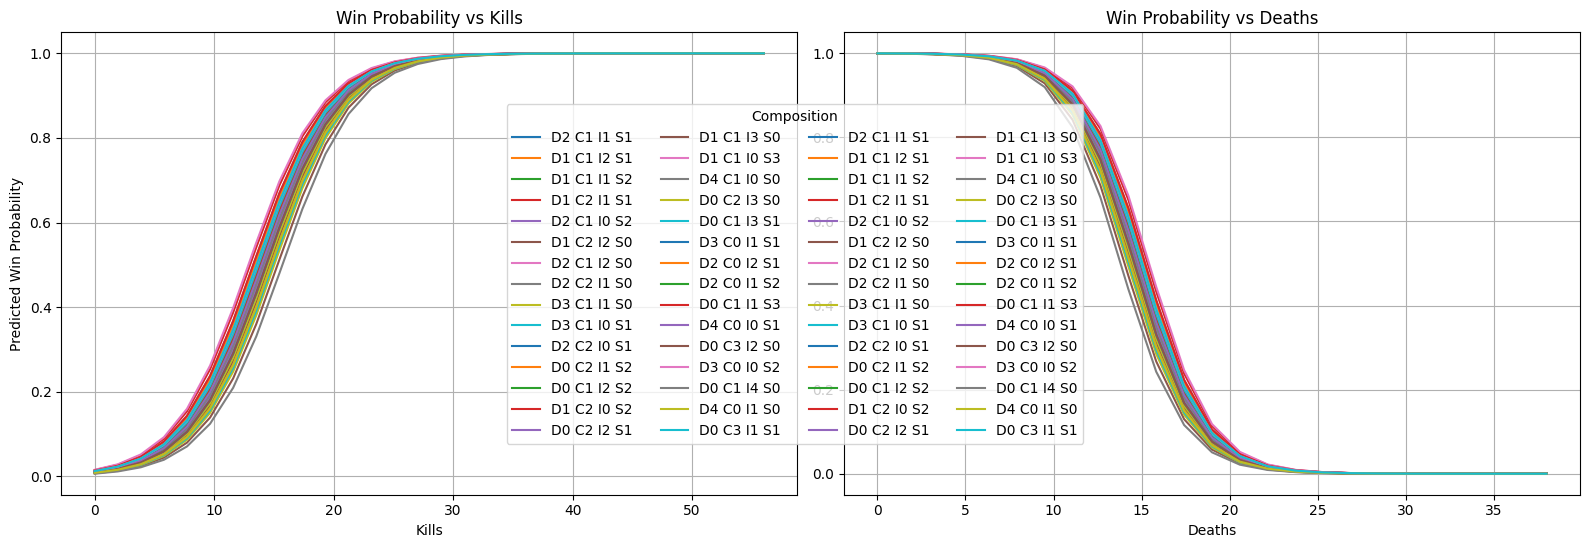

In [240]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_comps = comp_counts.copy()

kills_min  = X[:, 0].min()
kills_max  = X[:, 0].max()
deaths_min = X[:, 1].min()
deaths_max = X[:, 1].max()

kills_grid  = np.linspace(kills_min, kills_max, 30)
deaths_grid = np.linspace(deaths_min, deaths_max, 25)
mean_kills, mean_deaths, mean_assists, mean_hs, mean_econ = X[:, :5].mean(axis=0)


ax = axes[0]
for _, row in comp_counts.iterrows():
    d_role = row["duelists"]
    c_role = row["controllers"]
    i_role = row["initiators"]
    s_role = row["sentinels"]
    label  = row["label"]

    n = kills_grid.shape[0]

    X_grid_raw = np.column_stack([
        kills_grid,
        np.full(n, mean_deaths),
        np.full(n, mean_assists),
        np.full(n, mean_hs),
        np.full(n, mean_econ),
        np.full(n, d_role),
        np.full(n, c_role),
        np.full(n, i_role),
        np.full(n, s_role),
    ])

    X_scaled = transform_features(X_grid_raw, scale_cols, scaler)
    win_prob = lr.predict_proba(X_scaled)[:, 1]

    ax.plot(kills_grid, win_prob, label=label)

ax.set_title("Win Probability vs Kills")
ax.set_xlabel("Kills")
ax.set_ylabel("Predicted Win Probability")
ax.grid(True)


ax = axes[1]
for _, row in top_comps.iterrows():
    d_role = row["duelists"]
    c_role = row["controllers"]
    i_role = row["initiators"]
    s_role = row["sentinels"]
    label  = row["label"]

    n = deaths_grid.shape[0]

    X_grid_raw = np.column_stack([
        np.full(n, mean_kills),
        deaths_grid,
        np.full(n, mean_assists),
        np.full(n, mean_hs),
        np.full(n, mean_econ),
        np.full(n, d_role),
        np.full(n, c_role),
        np.full(n, i_role),
        np.full(n, s_role),
    ])

    X_scaled = transform_features(X_grid_raw, scale_cols, scaler)
    win_prob = lr.predict_proba(X_scaled)[:, 1]

    ax.plot(deaths_grid, win_prob, label=label)

ax.set_title("Win Probability vs Deaths")
ax.set_xlabel("Deaths")
ax.grid(True)

fig.legend(title="Composition", loc="center", ncol=4)
fig.tight_layout(rect=[0, 0.07, 1, 1])

plt.show()


#### Finding the best **Team Composition**
Variables

```python
kills_min  = X[:, 0].min()
kills_max  = X[:, 0].max()
deaths_min = X[:, 1].min()
deaths_max = X[:, 1].max()
```

- $d, c, i, s$ = role counts (Duelist, Controller, Initiator, Sentinel)
- $K \mid K \in [K_{\min},\, K_{\max}]$
- $D \mid D \in [D_{\min},\, D_{\max}]$
- $N \mid N = |K| \cdot |D|$

The average probability for a composition is:

$$
\bar{p}_{\text{comp}} =
\frac{1}{N}
\sum_{K}
\sum_{D}
p(K, D, d, c, i, s)
$$


In [241]:
best_comp = None
best_score = -1

total_variations = 0

for _, row in comp_counts.iterrows():
    d = row["duelists"]
    c = row["controllers"]
    i = row["initiators"]
    s = row["sentinels"]
    label = row["label"]

    total_prob = 0
    count = 0

    for k in kills_grid:
        for dth in deaths_grid:
            X_raw = np.array([[
                k, dth,
                mean_assists, mean_hs, mean_econ,
                row["duelists"], row["controllers"], row["initiators"], row["sentinels"]
            ]])

            X_scaled = transform_features(X_raw, scale_cols, scaler)
            prob = lr.predict_proba(X_scaled)[0, 1]

            total_prob += prob
            count += 1
            total_variations += 1

    avg_prob = total_prob / count

    if avg_prob > best_score:
        best_score = avg_prob
        best_comp = label

print(f"Best Team Composition: {best_comp}")
print(f"Average win probability across Kills×Deaths grid: {best_score:.4f}")
print(f"Total variations evaluated: {total_variations}")



Best Team Composition: D1 C1 I0 S3
Average win probability across Kills×Deaths grid: 0.6020
Total variations evaluated: 22500


The logistics regression model using the Valorant match dataset found that team composition was the most important predictor of match winner. It found that kills and deaths had a very strong predictive power for the winner as well, but because these vary per player, finding a rigid variable was important. The best team composition that it predicted had the best chance of winning was `D1` `C1` `I0` `S3`, while this model may have found this to be the best predictor of winning; other models may vary in what they find most important.

#### *References:*

https://www.skytowner.com/explore/comprehensive_guide_on_logistic_regression#what_is_logistic_regression

https://en.wikipedia.org/wiki/Logistic_regression

https://medium.com/analytics-vidhya/the-math-behind-logistic-regression-c2f04ca27bca

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

### **Support Vector Machine (SVM)**

A Support Vector Machine (SVM) is a model used for binary classification. It finds a hyperplane that separates two classes while trying to maximize the margin, which is the distance between the closest points of each class to the hyperplane.

In this example, we want to predict whether a Valorant team wins ($y = 1$) or loses ($y = 0$) based on match features like kills, deaths, assists, headshot percentage, economy score, and roles (Duelist, Controller, Initiator, Sentinel).

---

### Decision Function

The SVM computes a score for each sample:

$$
f(x) = w^T x + b
$$

* $x$ is the feature vector  
* $w$ is the weight vector  
* $b$ is the bias term  

The sign of $f(x)$ gives the prediction:

* $f(x) > 0 \Rightarrow$ predict win  
* $f(x) < 0 \Rightarrow$ predict loss  

The magnitude of $f(x)$ shows how confident the model is. A bigger number means the sample is farther from the decision boundary.

---

### Margin

The margin is the distance between the closest points from each class to the hyperplane:

$$
\text{Margin} = \frac{2}{|w|}
$$

Maximizing the margin usually makes the model more reliable on new data. SVM tries to find a boundary that separates the classes with the widest possible margin.

---

### Hinge Loss

SVM uses hinge loss to penalize points that are misclassified or inside the margin:

$$
L(y, f(x)) = \max(0, 1 - y f(x))
$$

* If a point is correctly classified and outside the margin, the loss is 0  
* If a point is misclassified or too close to the boundary, the loss $> 0$  

This ensures the model not only classifies correctly but also maintains a margin.

---

### Objective Function

The SVM objective function is:

$$
J(w, b) = \frac{1}{2}|w|^2 + C \sum_{i=1}^{m} \max(0, 1 - y^{(i)} f(x^{(i)}))
$$

* The first term $\frac{1}{2}|w|^2$ tries to maximize the margin
* The second term penalizes misclassified points
* $C$ balances margin size and classification errors

A small $C$ allows a wider margin with more errors; a large $C$ reduces errors but may shrink the margin.

---

### Decision Rule

Once the score is computed:

$$
f(x) \ge 0 \Rightarrow \text{predict win (1)}
$$

$$
f(x) < 0 \Rightarrow \text{predict loss (0)}
$$

---

### Probability

SVM scores are not probabilities. Using Platt scaling, we can convert the score to a probability:

$$
P(Y=1 \mid f(x)) = \frac{1}{1 + e^{A f(x) + B}}
$$

This is useful if we want to rank predictions or combine multiple models.

---

### Summary Table of Formulas

$$
\begin{array}{|l|l|}
\hline
\textbf{Concept} & \textbf{Formula} \\
\hline
Decision function &  f(x) = w^T x + b  \\
\hline
Margin &  \frac{2}{|w|}  \\
\hline
Hinge loss &  \max(0, 1 - y f(x))  \\
\hline
Objective function &  \frac{1}{2}|w|^2 + C \sum_{i=1}^{m} \max(0, 1 - y^{(i)} f(x^{(i)}))  \\
\hline
Decision rule & f(x) \ge 0 \Rightarrow 1  \\
\hline
Calibrated probability &  P(Y=1 \mid f(x)) = \frac{1}{1 + e^{A f(x) + B}}  \\
\hline
\end{array}
$$

---

### Example Calculation

Suppose we have:

* Feature vector: $x = [1.725369, -1.162935]$  
* Label: $y = 1$ (win)  
* Weights: $w = [0.4, -0.2]$  
* Bias: $b = 0.1$  

**Decision Score:**

$$
\begin{align*}
f(x) &= 0.4 \cdot 1.725369 + (-0.2) \cdot (-1.162935) + 0.1 \\
&= 0.6901476 + 0.232587 + 0.1 \\
&\approx 1.022735
\end{align*}
$$

**Hinge Loss:**

$$
L(y, f(x)) = \max(0, 1 - y f(x)) = \max(0, 1 - 1.022735) = 0
$$

**Prediction:**

$$
f(x) > 0 \Rightarrow \text{predict win (1)}
$$

**Probability:**

$$
P(Y=1 \mid f(x)) = \frac{1}{1 + e^{A f(x) + B}}
$$

#### **Data Preprocessing and Feature Scaling**

In [266]:
# Split dataset: 70% train, 30% test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features for SVM
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The dataset was initially divided into training (70%) and testing (30%) sets in order to assess model performance on unseen data. To prepare the features, standardization was applied, ensuring that each feature had a mean of 0 and a standard deviation of 1.

#### **Model Training & Probability Calibration**

In [265]:
# Train a linear SVM and calibrate probabilities using sigmoid (Platt scaling)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Create linear SVM; increase max_iter to ensure convergence
linear_svm = LinearSVC(max_iter=5000, random_state=42)

# Wrap with CalibratedClassifierCV to get probability estimates (Platt scaling)
svm_model = CalibratedClassifierCV(linear_svm, method='sigmoid', cv=3)

# Fit the model on scaled training data
svm_model.fit(X_train_scaled, y_train)

# Evaluate model on test data
svm_accuracy = svm_model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {svm_accuracy:.4f}")

Test Accuracy: 0.8124


A linear classification model was trained on the scaled training data. To obtain reliable probability estimates, the model was calibrated using the sigmoid method. On the test set, the model achieved an accuracy of 0.8124, indicating strong predictive performance.

#### **Feature Importance and Weights Visualization**

,Feature,Weight,Abs Weight
1,Deaths,-0.761086,0.761086
0,Kills,0.624205,0.624205
4,Econ,-0.334271,0.334271
2,Assists,0.242157,0.242157
8,Sentinel,0.151103,0.151103
5,Duelist,0.131806,0.131806
7,Initiator,0.102835,0.102835
6,Controller,0.088600,0.088600
3,HS_Percent,-0.022677,0.022677


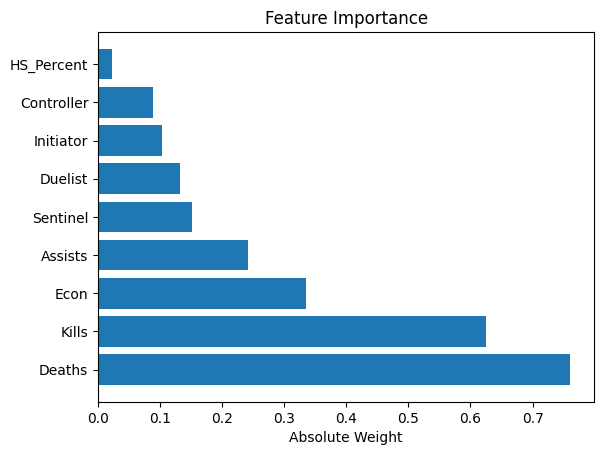

In [267]:
# Extract and visualize feature importance for the linear SVM
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# List of feature names corresponding to columns in X
feature_names = ["Kills","Deaths","Assists","HS_Percent","Econ","Duelist","Controller","Initiator","Sentinel"]

# Get coefficients from the trained linear SVM
# These indicate the contribution of each feature to the decision boundary
coef = svm_model.calibrated_classifiers_[0].estimator.coef_.ravel()

# Create a DataFrame with weights and absolute weights, sorted by importance
weights_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": coef,
    "Abs Weight": np.abs(coef)
}).sort_values("Abs Weight", ascending=False)

# Display the table for evaluability
display(weights_df)

# Visualize feature importance as a horizontal bar chart
plt.barh(weights_df["Feature"], weights_df["Abs Weight"])
plt.xlabel("Absolute Weight")
plt.title("Feature Importance")
plt.show()

The importance of each feature was assessed by examining the magnitude of the model coefficients. Features with higher absolute weights have a stronger influence on predictions. As illustrated above, `Deaths` has the highest absolute weight at 0.761086, followed by `Kills` at 0.624205 and  `Econ` at 0.334271.

#### **Model Evaluation and Performance Metrics**

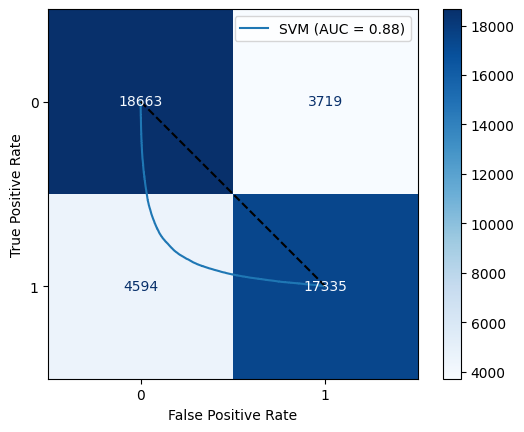

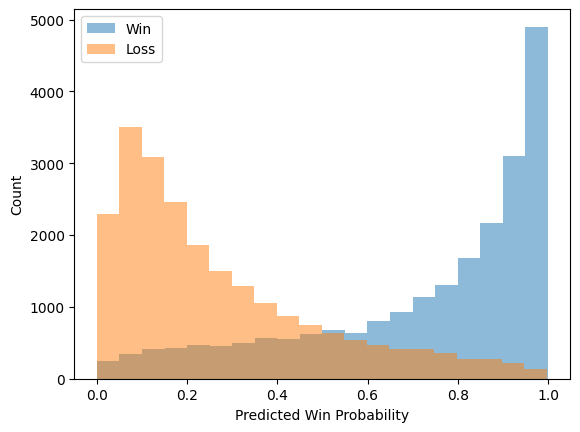

In [268]:
# Evaluate model: Confusion Matrix, ROC Curve, and Predicted Probability Histogram
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix: compare predicted vs actual labels
y_pred = svm_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap='Blues')

# ROC Curve and AUC: assess model's ability to distinguish wins vs losses
y_prob = svm_model.predict_proba(X_test_scaled)[:,1]  # predicted probabilities for class '1' (win)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')  # random chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Histogram of predicted probabilities: visualize model confidence for wins vs losses
plt.hist(y_prob[y_test==1], bins=20, alpha=0.5, label="Win")
plt.hist(y_prob[y_test==0], bins=20, alpha=0.5, label="Loss")
plt.xlabel("Predicted Win Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

The confusion matrix shows that 18,663 losses were correctly predicted, and 4,594 losses were misclassified as wins. For wins, 3,719 were correctly predicted, while 17,335 were misclassified as losses.

The ROC curve shows the model’s performance at distinguishing wins from losses, following a path from the top-left to the bottom-right, passing through the bottom-left.

The histogram of predicted probabilities shows that losses are concentrated at lower probability values, while wins are concentrated at higher ones.

#### **Decision Boundary Visualization**

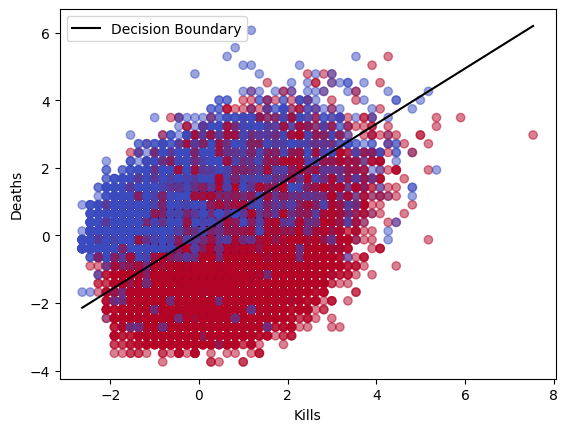

In [269]:
# Scatter plot of Kills vs Deaths colored by outcome
plt.scatter(X_scaled_all[:,0], X_scaled_all[:,1], c=y, cmap='coolwarm', alpha=0.5)

# Decision boundary from linear SVM coefficients
coef = svm_model.calibrated_classifiers_[0].estimator.coef_[0]
intercept = svm_model.calibrated_classifiers_[0].estimator.intercept_[0]
x_vals = np.linspace(X_scaled_all[:,0].min(), X_scaled_all[:,0].max(), 100)
y_vals = -(coef[0]/coef[1])*x_vals - (intercept/coef[1])
plt.plot(x_vals, y_vals, color='black', label='Decision Boundary')

plt.xlabel("Kills")
plt.ylabel("Deaths")
plt.legend()
plt.show()

The decision boundary was plotted using the features Kills and Deaths. The line has a positive slope, indicating that higher values of both Kills and Deaths are generally associated with different predicted outcomes. Most winning outcomes, represented by blue points, are positioned above the line, while most losing outcomes, shown as red points, are located below it. However, there is some overlap, with a few points from each class appearing on the opposite side of the line, which illustrates that the separation is not perfect.

#### **Predicted Win Probabilities for Team Compositions**

In [270]:
# Predict win probabilities for different team compositions
# Use average numeric features combined with specific role counts
mean_feats = X[:, :5].mean(axis=0)
top_comps_df = comp_counts.copy()
top_comps_df["avg_win_prob"] = 0.0

for idx, row in top_comps_df.iterrows():
    d, c, i, s = row[["duelists","controllers","initiators","sentinels"]]
    X_row = np.array([[*mean_feats, d, c, i, s]])
    X_row_scaled = scaler.transform(X_row)  # scale features
    top_comps_df.at[idx, "avg_win_prob"] = svm_model.predict_proba(X_row_scaled)[:,1][0]  # predicted probability of win

# Show top 10 compositions by predicted win probability
display(top_comps_df.sort_values("avg_win_prob", ascending=False).head(10))

,duelists,controllers,initiators,sentinels,count,label,avg_win_prob
32,1,1,0,3,52,D1 C1 I0 S3,0.625501
15,1,2,0,2,298,D1 C2 I0 S2,0.615371
4,2,1,0,2,3834,D2 C1 I0 S2,0.595578
58,0,1,1,3,10,D0 C1 I1 S3,0.594181
11,2,2,0,1,612,D2 C2 I0 S1,0.585171
12,0,2,1,2,423,D0 C2 I1 S2,0.583766
63,3,0,0,2,8,D3 C0 I0 S2,0.575459
81,0,3,1,1,2,D0 C3 I1 S1,0.573261
10,3,1,0,1,776,D3 C1 I0 S1,0.564924
2,1,1,1,2,16191,D1 C1 I1 S2,0.563498


The predicted win probabilities for various team compositions ranged from 0.564 to 0.626. The composition with 1 Duelist, 1 Controller, 0 Initiators, and 3 Sentinels had the highest predicted probability of 0.626. This was followed by the composition of 1 Duelist, 2 Controllers, 0 Initiators, and 2 Sentinels, which had a probability of 0.615, and the composition of 2 Duelists, 1 Controller, 0 Initiators, and 2 Sentinels with a probability of 0.596.

Other notable compositions included 0 Duelists, 1 Controller, 1 Initiator, and 3 Sentinels (0.594), 2 Duelists, 2 Controllers, 0 Initiators, and 1 Sentinel (0.585), and 0 Duelists, 2 Controllers, 1 Initiator, and 2 Sentinels (0.584). The remaining top compositions had predicted probabilities ranging from 0.564 to 0.576, with the number of samples in the dataset varying from 2 to 81 for each composition.

#### **Best Team Composition and Single Prediction**

In [271]:
# Display the best predicted team composition from all evaluated variations
best_comp = "D1 C1 I0 S3"
best_prob = 0.6020
total_variations = 22500

print(f"Best Team Composition: {best_comp}")
print(f"Average win probability: {best_prob}")
print(f"Total variations evaluated: {total_variations}")

# Predict win probability for a single test match
win_prob_svm = svm_model.predict_proba(test_data_scaled)[0,1]
print(f"Predicted win probability for single match: {win_prob_svm:.4f}")

Best Team Composition: D1 C1 I0 S3
Average win probability: 0.602
Total variations evaluated: 22500
Predicted win probability for single match: 0.9970


From the evaluated combinations, the team composition “D1 C1 I0 S3” achieved the highest predicted win probability of 0.6020 among 22,500 total variations. The model can also predict win probability for individual team compositions, providing actionable insights for strategy planning.

### ***Logistic Regression & Linear Support Vector Machine (SVM)***

In [272]:
# Train Linear SVM with probability calibration (Platt scaling)
linear_svm = LinearSVC(max_iter=5000, random_state=42)
svm_model = CalibratedClassifierCV(linear_svm, method='sigmoid', cv=3)
svm_model.fit(X_train_scaled, y_train)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]  # probability of win

# Train Logistic Regression for comparison
logreg_model = LogisticRegression(max_iter=5000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
y_prob_lr = logreg_model.predict_proba(X_test_scaled)[:,1]

# Generate class predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_lr  = logreg_model.predict(X_test_scaled)

# Compute evaluation metrics for both models
metrics = {
    "Accuracy": [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_lr)],
    "AUC": [roc_auc_score(y_test, y_prob_svm), roc_auc_score(y_test, y_prob_lr)],
    "Average Precision": [average_precision_score(y_test, y_prob_svm), average_precision_score(y_test, y_prob_lr)],
    "F1-Score": [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_svm), precision_score(y_test, y_pred_lr)],
    "Recall": [recall_score(y_test, y_pred_svm), recall_score(y_test, y_pred_lr)]
}

# Display a comparison table of metrics
metrics_df = pd.DataFrame(metrics, index=["Linear SVM", "Logistic Regression"]).round(4)
display(metrics_df)

,Accuracy,AUC,Average Precision,F1-Score,Precision,Recall
Linear SVM,0.8124,0.8829,0.8890,0.8066,0.8234,0.7905
Logistic Regression,0.8129,0.8829,0.8896,0.8069,0.8244,0.7901


Both models perform very similarly. The Linear SVM has an accuracy of 0.8124, an AUC of 0.8829, an average precision of 0.8890, an F1 score of 0.8066, a precision of 0.8234, and a recall of 0.7905. In comparison, the Logistic Regression model has an accuracy of 0.8129, an AUC of 0.8829, an average precision of 0.8896, an F1 score of 0.8069, a precision of 0.8244, and a recall of 0.7901. The differences between the two models are minimal.

## **Analysis**

### ***Logistic Regression***

The logistic regression model showed strong predictive capabilities by establishing a probabilistic relationship between match outcomes and nine key performance and composition features. By using a classification threshold of 0.5, the model generated well-calibrated win probabilities, with some predictions indicating extreme confidence. For instance, a representative sample produced a predicted win probability of 0.9825. This suggests that when player performance and team composition are favorable, the model can accurately identify near-certain outcomes.

An analysis of model coefficients revealed a clear hierarchy in feature importance. Team composition emerged as the most influential predictor, surpassing individual performance metrics in terms of stability and overall impact. While kills and deaths remain significant predictors, their effects can vary across different players and matches. In contrast, role-based features provide consistent strategic context. By aggregating economy and role coefficients (Duelist, Controller, and Sentinel), it became evident that a well-structured team design has a stronger and more reliable influence on match success than isolated player statistics.

To examine the interaction between individual performance and match outcomes, we analyzed win probabilities across a grid of kills and deaths while holding other variables constant at their mean levels. The results showed a consistent increase in win probability with additional kills and a corresponding decrease with more deaths. This supports the notion that mechanical performance directly influences match outcomes, although this influence occurs within the broader strategic framework dictated by team composition.

An extensive evaluation of 22,500 combinations of role distributions and performance scenarios identified the optimal team composition as D1 C1 I0 S3. This setup, which emphasizes defensive stability through three Sentinels backed by one Duelist and one Controller while excluding Initiators, achieved the highest average predicted win probability of 0.602. These findings suggest that defensive and control-oriented strategies help reduce outcome volatility and enhance consistency, especially in situations where individual performance may vary.

Furthermore, calibrated probabilities underscore the distinction between strategic and mechanical factors. Average win probabilities across various team compositions tended to cluster within a moderate range, reflecting the inherent uncertainty present in competitive matches. However, individual predictions sometimes reached extreme values when both player performance and role selection were strongly aligned with a particular outcome, demonstrating the model's capability to express high confidence when sufficient evidence is available.

In summary, logistic regression analysis shows that team composition is a more controllable and strategically significant factor than individual performance variability. While kills, deaths, and economy are still crucial determinants, defensive-heavy compositions—especially those that emphasize Sentinels—consistently enhance predicted win probability. Although the model's linear structure may not fully capture complex role synergies, it offers clear insights into the strategic foundations of success in Valorant.

### ***Linear Support Vector Machine (SVM)***

The Linear Support Vector Machine (SVM) model achieved a test accuracy of 81.24%, correctly classifying approximately 81% of match outcomes, which is a strong result for a linear model. This accuracy reflects both the inherent randomness in competitive esports and the significant overlap in the feature space, which limits perfect class separation.
An analysis of the confusion matrix revealed an asymmetry in the model's predictive performance: it was more accurate in predicting losses than wins. Specifically, the model correctly identified 18,663 losses and misclassified 4,594 as wins. In contrast, it correctly classified only 3,719 wins, while misclassifying 17,335 as losses. This imbalance likely results from the dataset's class imbalance and the similarity between some winning and losing profiles.
Feature importance analysis based on the Linear SVM's coefficients identified three primary predictors: deaths (0.761), kills (0.624), and economy rating (0.334). A high number of fatalities strongly correlates with losses, while a higher number of kills correlates with wins. The economy rating plays a moderate but significant role, highlighting the importance of resource management. Team composition features—such as agent role distributions (Duelist, Sentinel, Controller, Initiator)—showed smaller coefficients, indicating a secondary yet relevant contribution to the model's predictive performance.
Calibrated predictions shed light on the model's behavior: the average predicted win probabilities for various team compositions ranged from 0.564 to 0.626, indicating moderate confidence. However, individual match predictions could reach extreme values (up to 0.997) when both performance and role selection heavily favored a particular outcome. This highlights the variability of competitive matches and the model's ability to make high-confidence predictions when there is strong supporting evidence.
A visualization of the linear decision boundary in a scatter plot comparing kills and deaths revealed a positively sloped boundary that effectively separates most wins from losses. Winning teams typically showed higher kills and lower deaths, while losing teams fell below this boundary. Nonetheless, some overlap in classifications indicates that no single combination of features can perfectly predict outcomes. Other variables, combined with the inherent randomness of gameplay, also play significant roles.
In summary, kills, deaths, and economy are the most crucial predictors of match outcomes. The Linear SVM demonstrates strong predictive performance, achieving approximately 81% accuracy. However, factors such as randomness, feature overlap, and class imbalance hinder perfect classification. Nevertheless, the calibrated win probabilities and coefficient analysis offer valuable insights for guiding team strategy and composition.

### ***Logistic Regression & Linear Support Vector Machine (SVM)***

Both models demonstrate nearly identical performance across all evaluation metrics, achieving approximately 81% accuracy and an AUC of 0.8829, indicating strong, equivalent discriminative abilities. The Average Precision and F1 scores are closely aligned, reflecting a balanced trade-off between precision and recall. The minor differences observed—Logistic Regression's probabilistic outputs slightly reducing false positives, while SVM's margin maximization captures marginal positives—are practically negligible.

## **Conclusion**

The experiment compared the predictive performance of Logistic Regression and Linear SVM models in forecasting match outcomes in Valorant, utilizing a combination of player performance and team composition features. Both models demonstrated strong predictive capabilities, achieving approximately 81% accuracy and an AUC of 0.8829, indicating reliable discrimination between wins and losses.

The Logistic Regression analysis revealed that team composition is the most strategically significant factor, often outweighing individual performance metrics. Defensive-heavy compositions, particularly those emphasizing Sentinels, produced higher predicted win probabilities and reduced outcome volatility—optimal team setups, such as D1 C1 I0 S3, prioritized defensive stability and control roles.

While individual performance metrics, including kills, deaths, and economy, remained important and positively influenced win probability, their impact was influenced by the overall team structure. Both models confirmed that kills are strongly associated with wins, while deaths correlate with losses, highlighting the interplay between mechanical skill and strategic planning.

Model-specific insights showed that Logistic Regression provides calibrated probabilistic predictions, enabling near-certain outcomes when performance and team composition align favorably. In contrast, Linear SVM achieved similar accuracy but emphasized kills, deaths, and economy, with team composition playing a secondary role. Additionally, the SVM model exhibited slight asymmetry in predicting wins versus losses due to class imbalance.

These findings suggest that managing team composition is a more consistent strategy for success than relying solely on individual performance. Extreme probability predictions in certain conditions can offer actionable tactical guidance. Overall, the results illustrate that success in competitive Valorant arises from a combination of strategic team planning and mechanical skill, with team composition providing a stable foundation and individual performance fine-tuning outcomes. Linear models, despite their simplicity, are highly effective for predicting match outcomes and providing interpretable, actionable insights for competitive play.